# 上海单城一步联合预测与 O3 站点因果图实验

本 notebook 现在只保留实验主线，把训练、缓存、评估和因果图实现打包到 `yrd.shanghai_notebook` 里，便于一眼看懂每个 cell 的职责。

- 数据时间分辨率保持原始 `1h`
- 每个样本输入为当前时刻全部站点联合快照，形状为 `19 x 10`
- 模型内部展平后的有效输入维度为 `190`
- 当前展示 `1h` 的 `O3` pairwise EI 图、`O3 + PM2.5 -> O3` 条件协同图，以及 `Syn / EI_joint` 比例图
- notebook 顶部提供醒目的因果图可调参数，包括干预盒宽 `L` 和图显示边比例
- notebook 只负责“配置 -> 运行 -> 展示”


In [1]:
from __future__ import annotations

from dataclasses import replace

import os
import sys
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    has_repo = (candidate / "yrd").is_dir() and (candidate / "data").is_dir()
    has_air_data = (candidate / "data" / "dataset_yrd.nc").exists() and (candidate / "data" / "stations_yrd.csv").exists()
    if has_repo and has_air_data:
        ROOT = candidate
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise RuntimeError("Could not locate project root containing yrd/ and data/")

from IPython.display import Image, display

from yrd.shanghai_notebook import (
    build_default_shanghai_one_step_config,
    build_prediction_tables,
    build_run_tag,
    compute_station_causal_graph_results,
    configure_notebook_runtime,
    prepare_shanghai_one_step_bundle,
    run_or_load_one_step_predictions,
    write_shanghai_one_step_conclusion,
)

configure_notebook_runtime()


In [8]:
NOTEBOOK_TEST_MODE = os.getenv("YRD_NOTEBOOK_TEST_MODE", "0") == "1"
FORCE_RETRAIN = False
FORCE_RECOMPUTE_COUPLING = False

# === 因果图可调参数：直接改这里 ===
# L: 训练集输入均值居中的均匀干预盒边长
CAUSAL_GRAPH_L = 10 #build_default_shanghai_one_step_config(ROOT, test_mode=NOTEBOOK_TEST_MODE).box_size
# 只控制 pairwise / 协同因果图显示时保留前多少比例的强边；不影响 EI/度分布诊断图
CAUSAL_GRAPH_EDGE_KEEP_FRACTION = 0.4
# 控制所有因果图箭头头部大小；值越大，方向越醒目
CAUSAL_GRAPH_ARROW_MUTATION_SCALE = 24.0
# 控制箭头头部离目标节点还保留多少距离；值越小，箭头越贴近目标节点
CAUSAL_GRAPH_ARROW_SHRINK_TARGET = 6.0

default_cfg = build_default_shanghai_one_step_config(ROOT, test_mode=NOTEBOOK_TEST_MODE)
cfg = replace(default_cfg, box_size=CAUSAL_GRAPH_L)
bundle = prepare_shanghai_one_step_bundle(
    cfg=cfg,
    city_en="shanghai",
    run_tag=build_run_tag(test_mode=NOTEBOOK_TEST_MODE),
    use_smoke=NOTEBOOK_TEST_MODE,
    coupling_sample_count=4 if NOTEBOOK_TEST_MODE else 16,
    graph_edges_per_target=1 if NOTEBOOK_TEST_MODE else 2,
    causal_graph_edge_keep_fraction=CAUSAL_GRAPH_EDGE_KEEP_FRACTION,
    causal_graph_arrow_mutation_scale=CAUSAL_GRAPH_ARROW_MUTATION_SCALE,
    causal_graph_arrow_shrink_target=CAUSAL_GRAPH_ARROW_SHRINK_TARGET,
    causal_graph_variable="O3",
)

artifact_paths = bundle["artifact_paths"]
run_context = bundle["run_context"]
sample_bundle = bundle["sample_bundle"]
run_context


{'run_tag': 'shanghai_one_step_o3_station_graph',
 'city_en': 'shanghai',
 'test_mode': False,
 'use_smoke': False,
 'sample_mode': 'one_step',
 'data_resolution_hours': 1,
 'history_hours': 1,
 'horizons': [1],
 'epochs': 12,
 'batch_size': 64,
 'hidden_dim': 96,
 'model_name': 'resmlp',
 'num_layers': 3,
 'dropout': 0.05,
 'norm_type': 'layernorm',
 'activation': 'silu',
 'station_count': 19,
 'input_shape': [19, 10],
 'effective_input_dim': 190,
 'full_effective_input_dim': 190,
 'train_samples': 52607,
 'val_samples': 8760,
 'test_samples': 8760,
 'coupling_sample_count': 16,
 'graph_edges_per_target': 2,
 'causal_graph_variable': 'O3',
 'requested_causal_graph_box_size': 10.0,
 'causal_graph_box_size': 10.0,
 'causal_graph_sampling_mode': 'uniform_box_centered_at_train_mean',
 'causal_graph_center_source': 'train_input_mean',
 'causal_graph_sampling_seed': 0,
 'causal_graph_edge_keep_fraction': 0.4,
 'causal_graph_arrow_mutation_scale': 24.0,
 'causal_graph_arrow_shrink_target': 6

In [9]:
predictions = run_or_load_one_step_predictions(bundle, force_retrain=FORCE_RETRAIN)
joint_model = predictions["joint_model"]
loss_history_payload = predictions["loss_history_payload"]

{
    "best_epoch": int(loss_history_payload["best_epoch"]),
    "best_val_loss": float(loss_history_payload["best_val_loss"]),
    "checkpoint": str(artifact_paths["checkpoint"]),
}


/Users/yangmingzhe/Desktop/code/github/EISyn/yrd/shanghai_notebook.py:998: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_payload = torch.load(artifact_paths["chec

{'best_epoch': 56,
 'best_val_loss': 0.048114243894815445,
 'checkpoint': '/Users/yangmingzhe/Desktop/code/github/EISyn/exp/cache/yrd_coupling/shanghai_one_step_o3_station_graph/joint_model_checkpoint.pt'}

## 一步预测评估

这里先确认一步联合模型是否在上海多站点任务上带来稳定收益，再进入基于一步代理动力学的 `O3` 站点因果图。


In [4]:
metrics_bundle = build_prediction_tables(bundle, predictions)
metrics_frame = metrics_bundle["metrics_frame"]
metrics_overall_df = metrics_bundle["metrics_overall_df"]
metrics_pollutant_df = metrics_bundle["metrics_pollutant_df"]
station_metrics_df = metrics_bundle["station_metrics_df"]

metrics_overall_df, metrics_pollutant_df.head(), station_metrics_df.head()


(                 model horizon    scope       rmse       mae      corr
 0  PersistenceBaseline      1h  overall  10.087296  6.239973  0.967226
 1      JointStationMLP      1h  overall   8.588140  5.720481  0.975970,
                  model horizon  scope       rmse       mae      corr
 0  PersistenceBaseline      1h     O3  12.976127  8.738608  0.951490
 1  PersistenceBaseline      1h  PM2.5   5.926822  3.741336  0.964041
 2      JointStationMLP      1h     O3  10.588912  7.496774  0.967164
 3      JointStationMLP      1h  PM2.5   5.948715  3.944188  0.963328,
                  model horizon station_id       rmse       mae      corr
 0  PersistenceBaseline      1h      1141A   9.903348  6.331792  0.971078
 1  PersistenceBaseline      1h      1142A   9.824844  6.192180  0.966468
 2  PersistenceBaseline      1h      1143A   9.849519  6.354338  0.966889
 3  PersistenceBaseline      1h      1144A   9.947832  6.210731  0.968841
 4  PersistenceBaseline      1h      1145A  10.427306  6.32220

## O3 因果图、条件协同图与比例图

这一节复用当前训练好的 `JointStationMLP`，在统一的全局干预盒宽 `L` 下，对每个目标站点的未来 `O3` 单变量提取局部 Jacobian。随后分别画出站点级 `O3` pairwise EI 图、`O3 + PM2.5 -> O3` 条件协同图，以及 `Syn / EI_joint` 比例图。

下面还会额外给出三类诊断信息：

1. 图中每条边的数学定义，以及它如何进一步映射成线宽和透明度。
2. 当前显示边的 `EI` 分布。
3. 当前显示图上的节点入度、出度分布；如果图是正权完全有向图，也会明确说明这一点，并额外展示加权入强度/出强度分布。

### 图中边权、线宽与透明度的数学定义

对任意均匀干预样本 $s$、目标站点 $j$、源站点 $i$，记模型在当前输入处对下一小时目标站点 `O3` 的局部 Jacobian 为

$$
\mathbf{J}_j^{(s)} = \frac{\partial f_j(\mathbf{x}^{(s)})}{\partial \mathbf{x}}.
$$

设源站点 $i$ 在当前时刻对应的输入维度集合为 $S_i$，其补集为 $\bar{S}_i$；残差协方差为 $\mathbf{\Sigma}_{\varepsilon,j}$；统一干预盒宽为 $L$。代码中先构造

$$
\mathbf{\Sigma}_{\mathrm{eff},j}^{(s)}(S_i)
=
\mathbf{\Sigma}_{\varepsilon,j}
+
\frac{L^2}{12}\,
\mathbf{J}_{j,\bar{S}_i}^{(s)}
\bigl(\mathbf{J}_{j,\bar{S}_i}^{(s)}\bigr)^\top,
$$

再计算该源站点对子目标站点的 station-level EI/NIS：

$$
\mathrm{EI}_{i \to j}^{(s)}
=
|S_i|\log L
-
\frac{|S_i|}{2}\log(2\pi e)
+
\frac{1}{2}\log \det_+
\left(
\bigl(\mathbf{J}_{j,S_i}^{(s)}\bigr)^\top
\mathbf{\Sigma}_{\mathrm{eff},j}^{(s)}(S_i)^{-1}
\mathbf{J}_{j,S_i}^{(s)}
\right).
$$

其中 $\det_+(\cdot)$ 表示只对正特征值求积，这对应 `yrd/coupling.py::_subset_ei_nis` 的实现。

其中干预样本 $\mathbf{x}^{(s)}$ 不是直接复用测试集观测，而是在以训练集输入均值为中心、边长为 $L$ 的输入盒内独立均匀采样得到。

图上的边权不是单个样本值，而是跨这批均匀干预样本的平均值：

$$
w_{i \to j} = \frac{1}{N}\sum_{s=1}^{N} \mathrm{EI}_{i \to j}^{(s)}.
$$

当前图只显示满足 $i \neq j$ 且 $w_{i \to j} > 0$ 的边。随后将其按全图最大边权归一化：

$$
n_{i \to j} = \frac{w_{i \to j}}{\max_{(u,v)} w_{u \to v}},
$$

并映射成绘图参数：

$$
\mathrm{linewidth}_{i \to j} = 0.3 + 4.1\,n_{i \to j},
\qquad
\alpha_{i \to j} = 0.08 + (0.82 - 0.08)\,n_{i \to j}.
$$

### 如何理解这张图

- 边越粗、越深，表示该边的平均 EI 越大。
- 线宽和透明度是对 EI 的线性视觉编码，并不直接等于 EI 数值本身。
- 因此，这张图在“边的相对强弱排序”上是忠实反映 EI 的；若要读取具体数值，应查看下面输出的边权表或导出的 `csv`。
- 下面的诊断图会分别展示：显示边的 EI 分布、节点入度分布、节点出度分布，以及加权入强度 / 出强度分布。
- 如果入度和出度分布退化成单点，说明当前显示图接近或等于完全有向图；这时真正有区分度的是加权强度，而不是边条数。

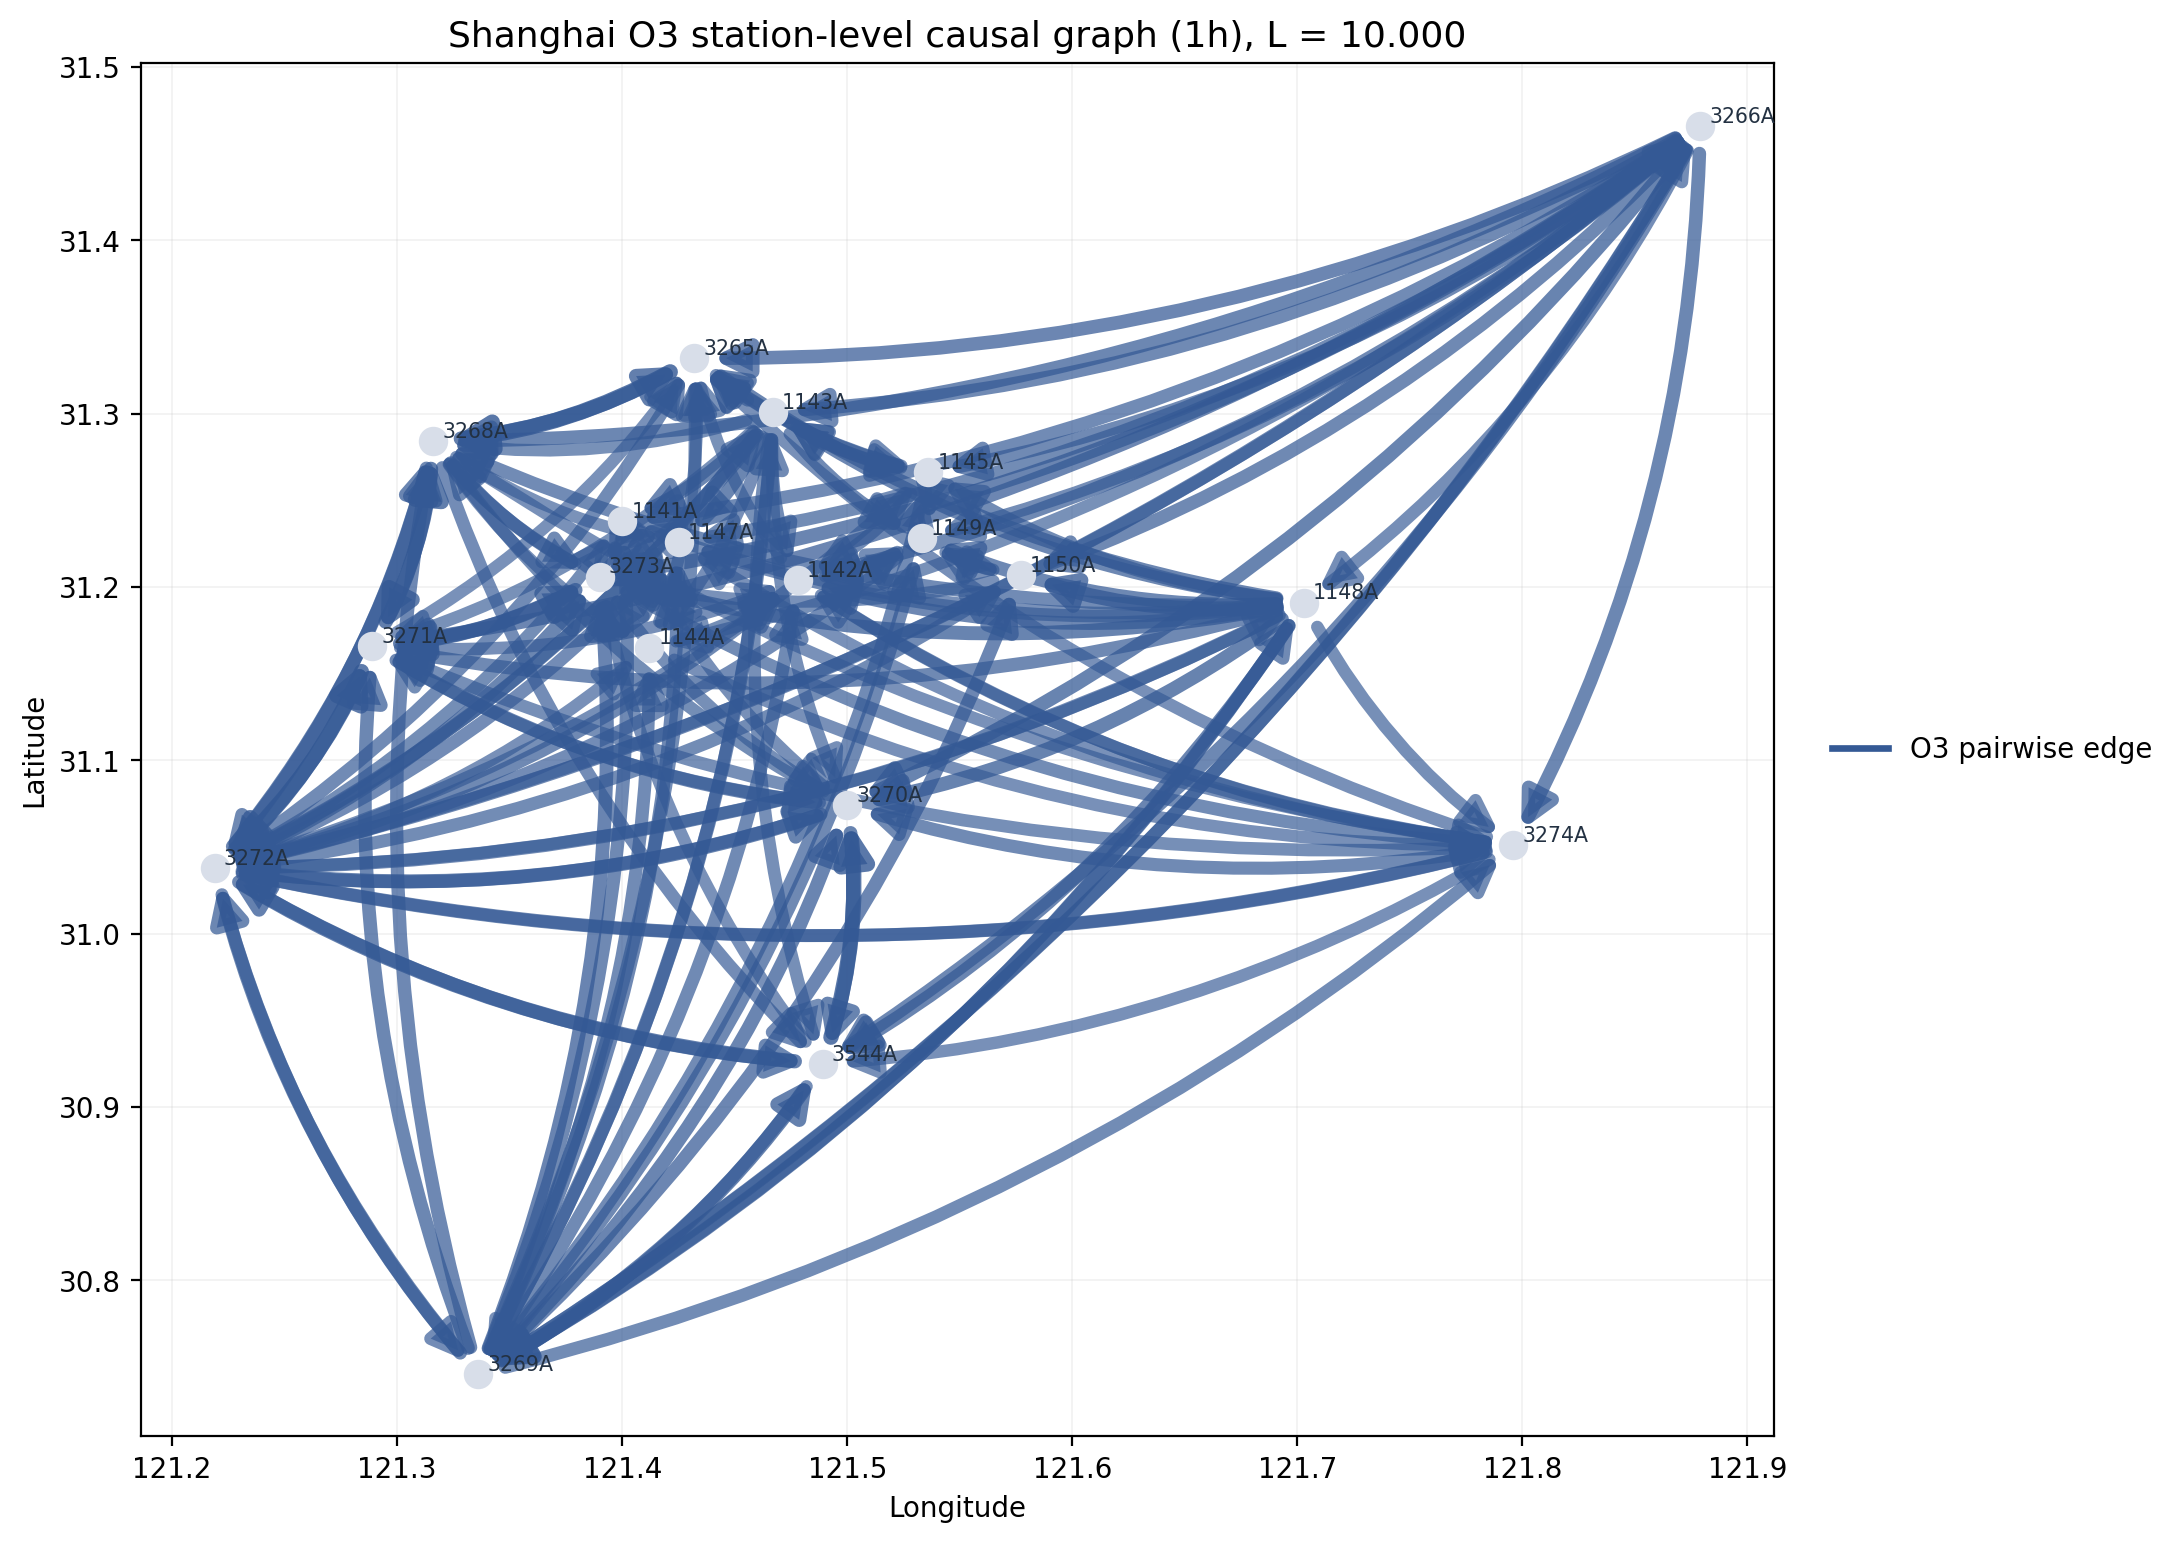

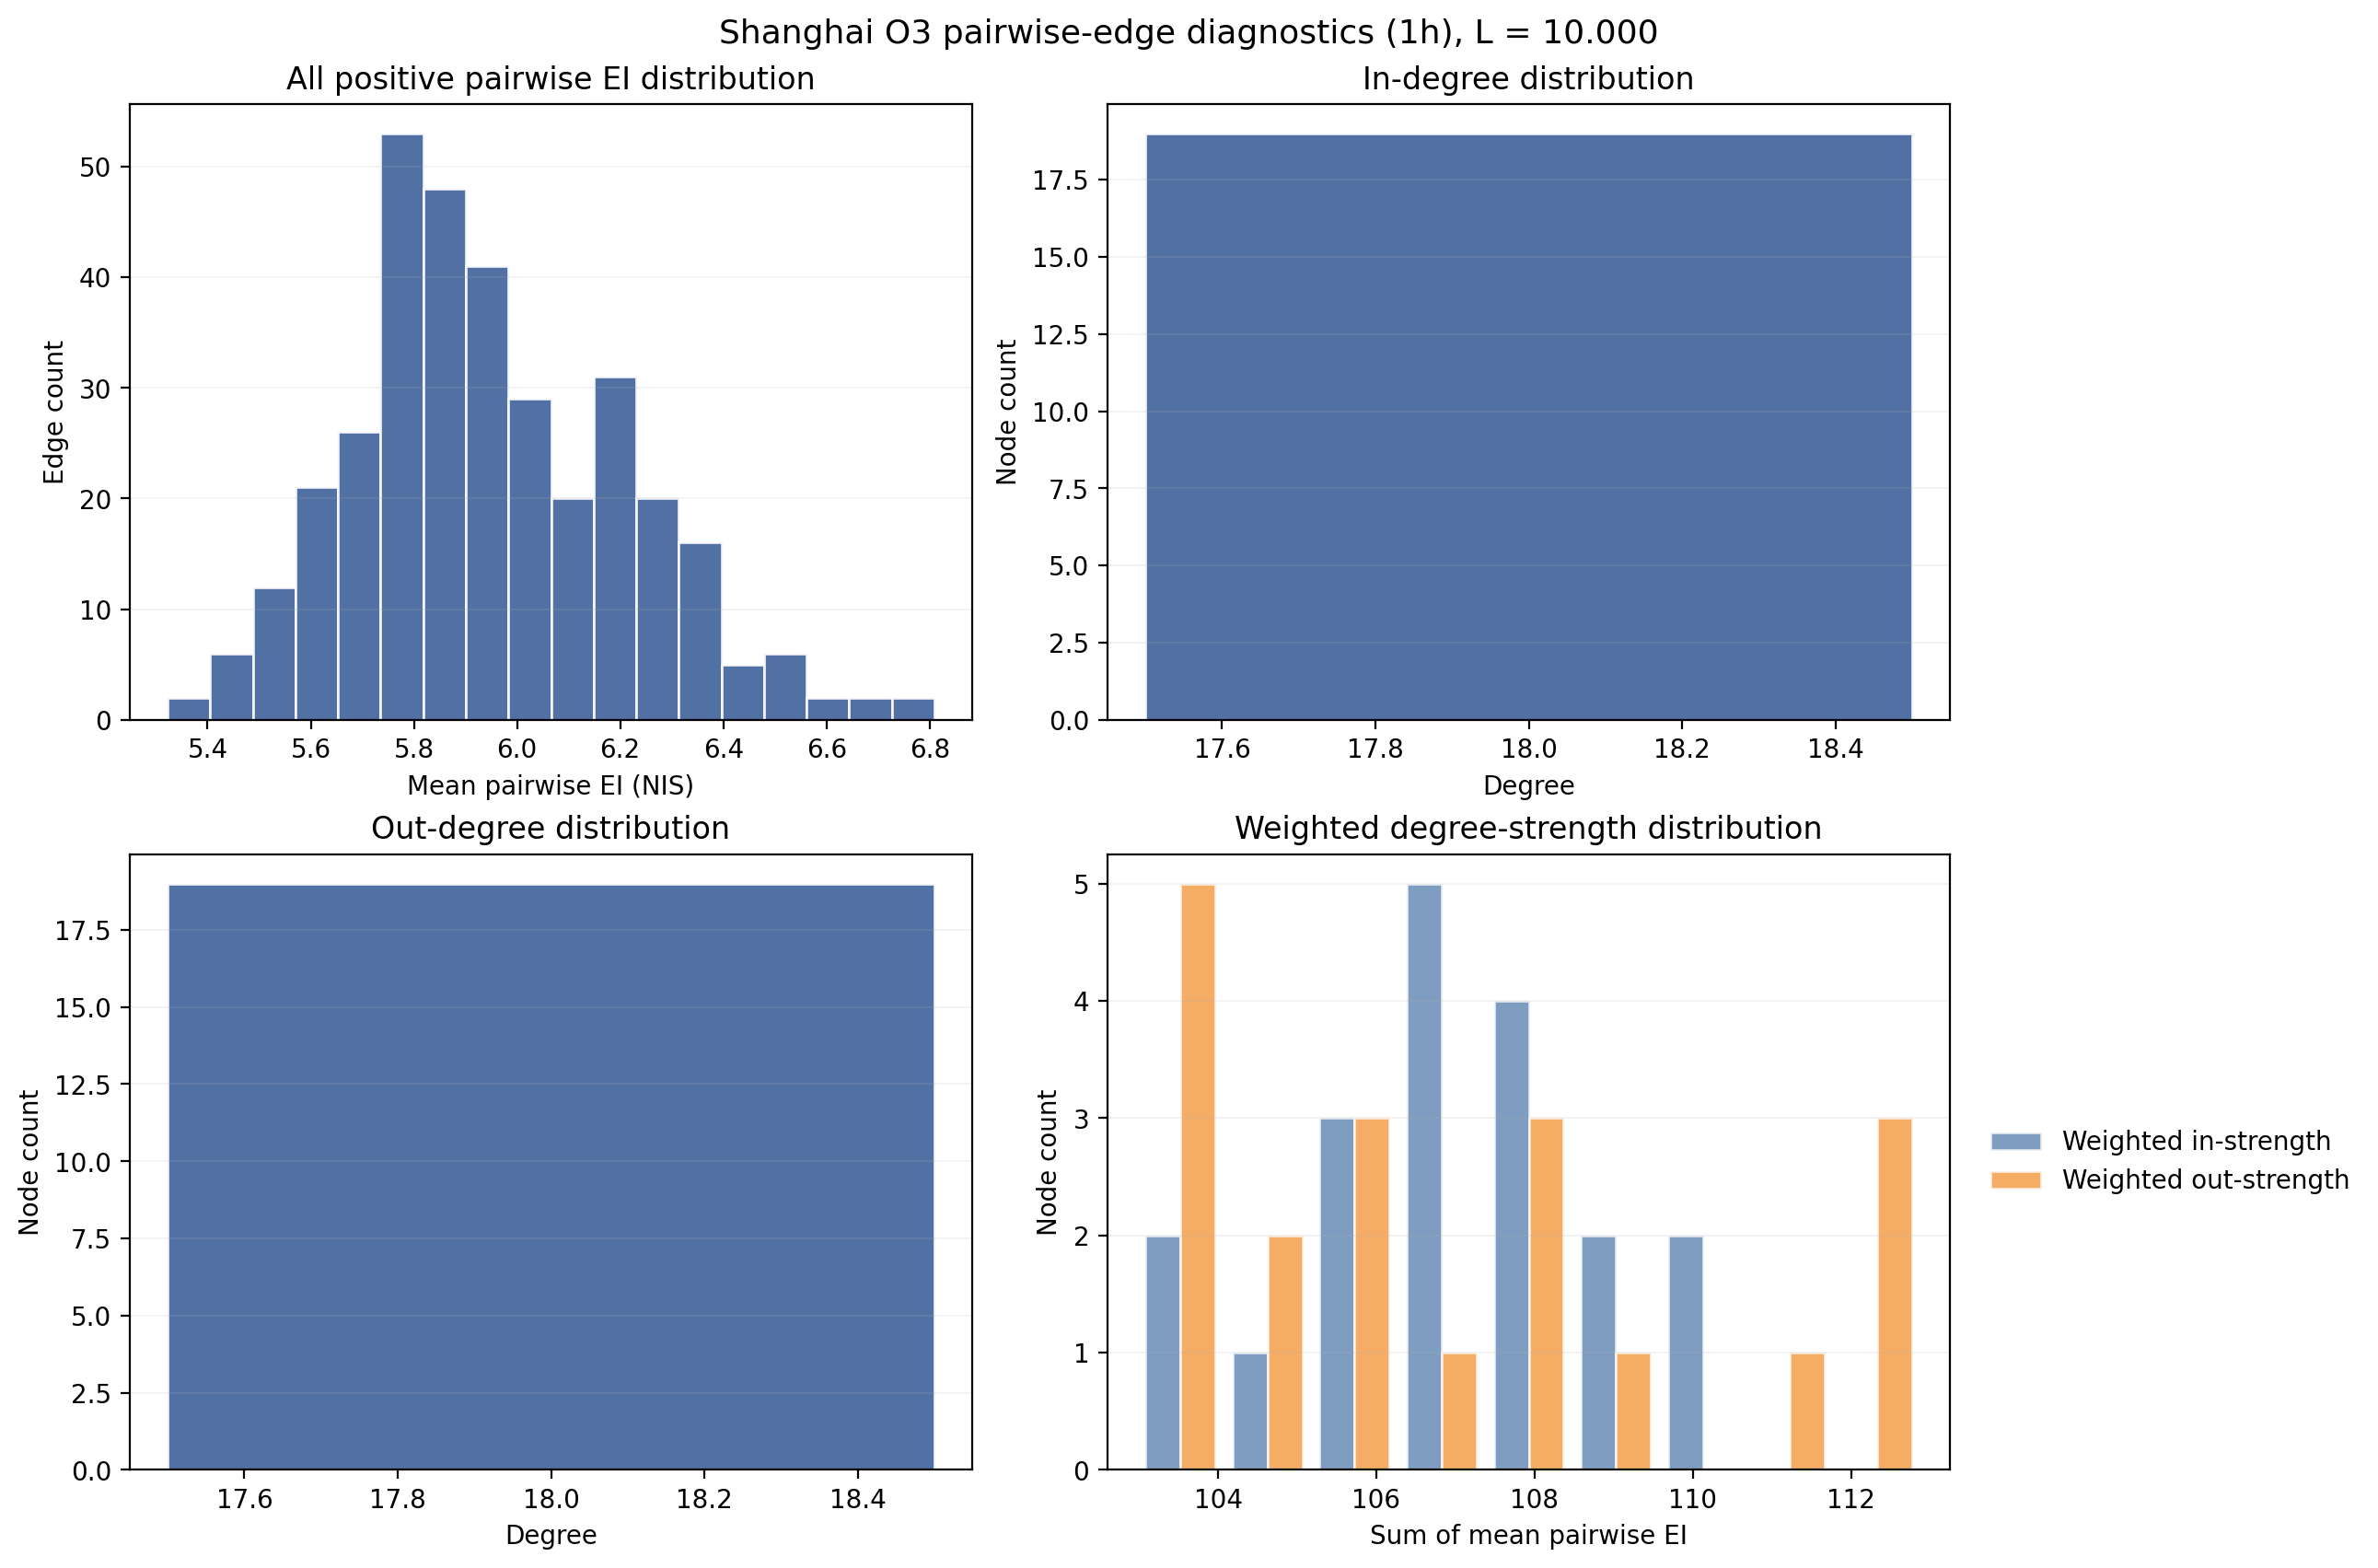

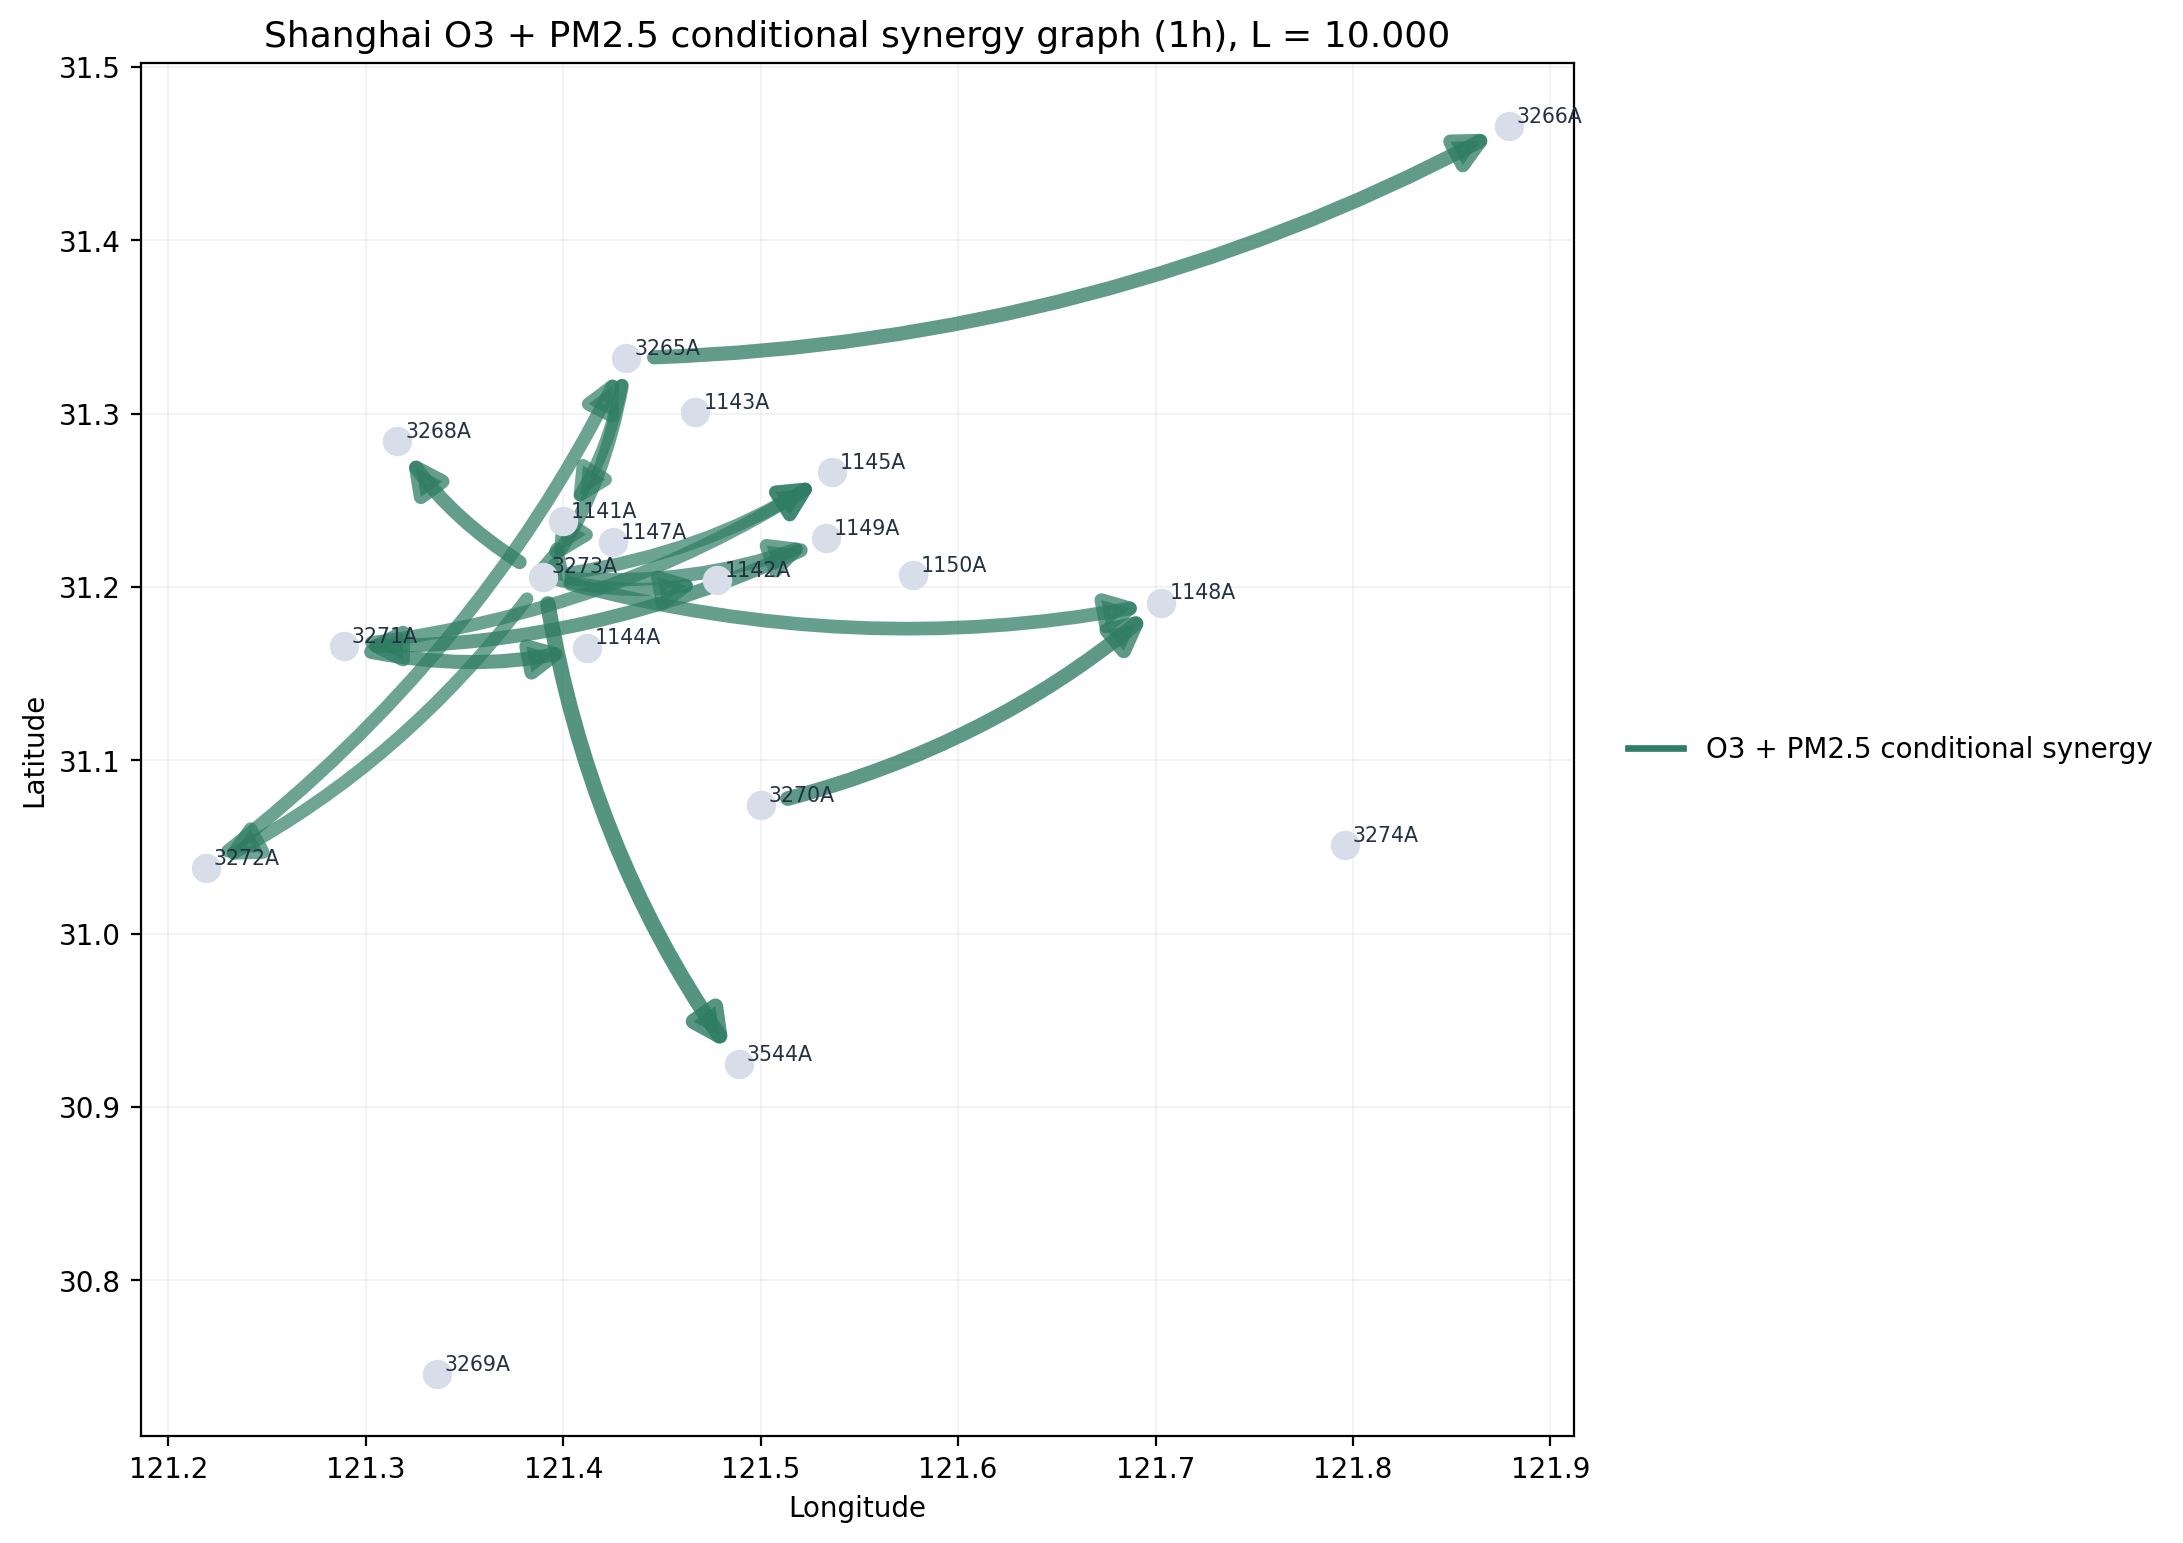

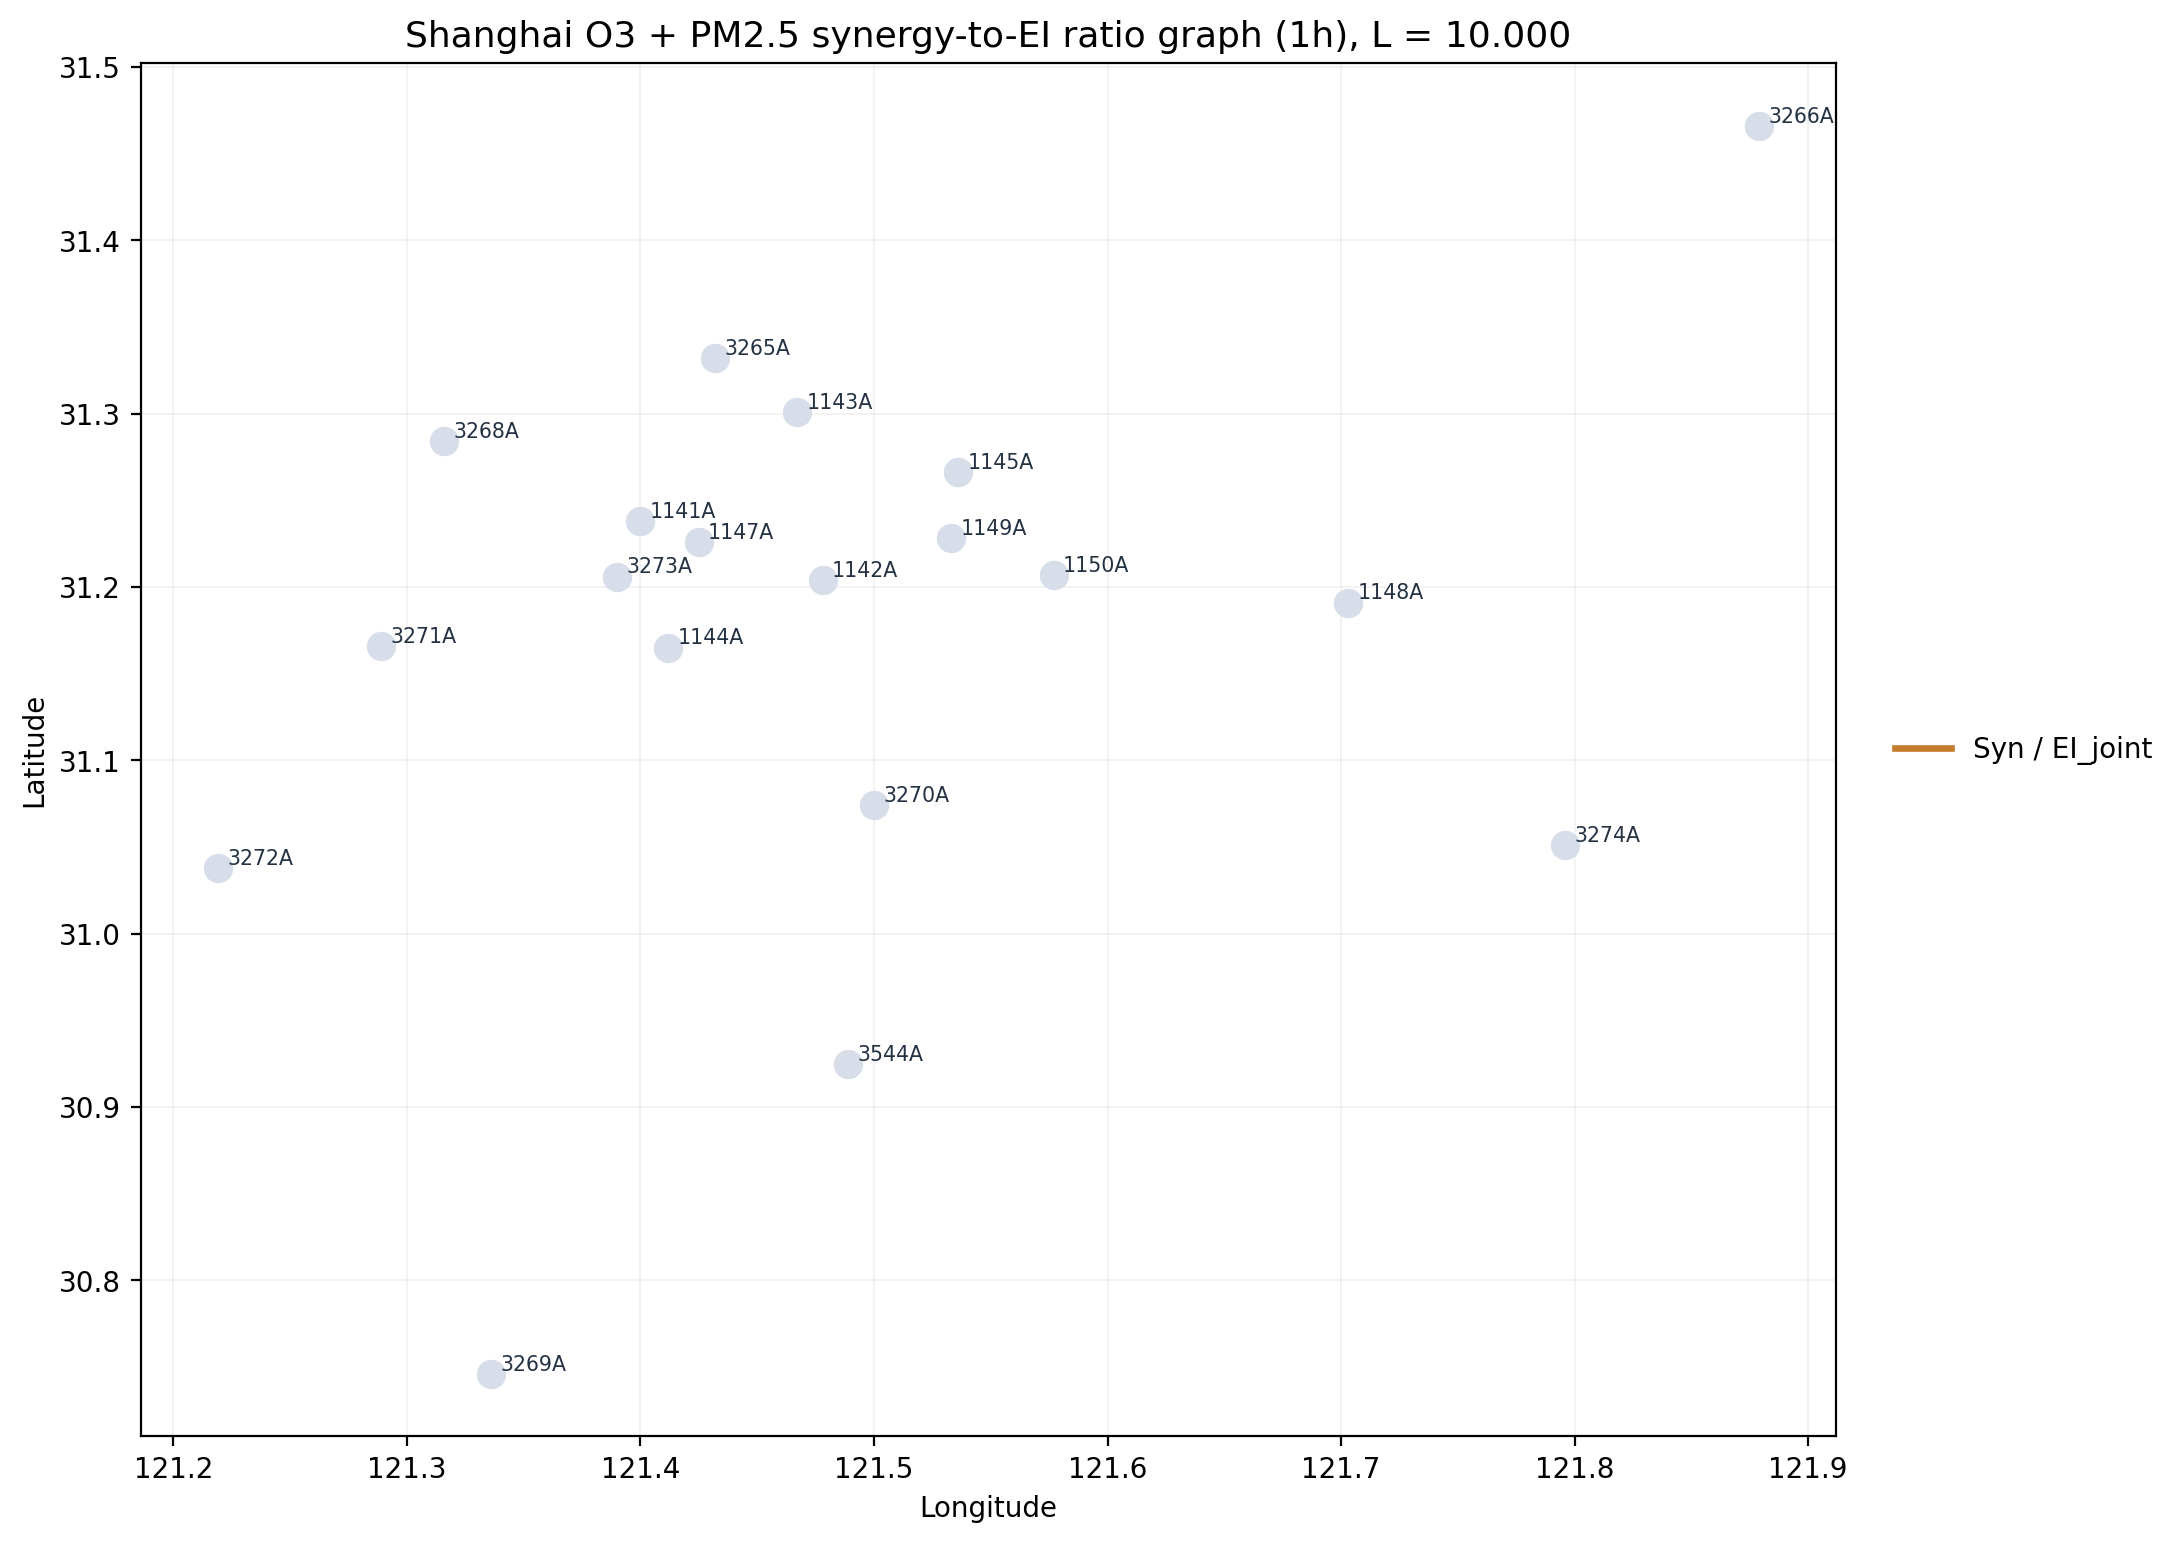

(   source_station_id target_station_id      mean  normalized_strength  \
 0              3265A             3268A  6.808951             1.000000   
 1              3544A             3270A  6.769225             0.994166   
 2              3271A             3272A  6.674102             0.980195   
 3              3272A             3271A  6.647162             0.976239   
 4              3271A             3268A  6.594289             0.968474   
 5              3268A             3271A  6.578425             0.966144   
 6              3268A             3265A  6.549306             0.961867   
 7              1148A             1150A  6.547674             0.961627   
 8              3271A             3273A  6.520965             0.957705   
 9              3269A             3544A  6.511501             0.956315   
 10             3544A             3272A  6.503542             0.955146   
 11             3273A             3271A  6.485634             0.952516   
 12             1148A             3270

In [10]:
causal_bundle = compute_station_causal_graph_results(
    bundle,
    predictions,
    force_recompute=FORCE_RECOMPUTE_COUPLING,
)
pairwise_display_1h = causal_bundle["pairwise_display_1h"]
pairwise_render_edges_1h = causal_bundle["pairwise_render_edges_1h"]
pairwise_degree_summary_1h = causal_bundle["pairwise_degree_summary_1h"]
binary_hyperedges_display_1h = causal_bundle["binary_hyperedges_display_1h"]
binary_hyperedges_global_ranked_1h = causal_bundle["binary_hyperedges_global_ranked_1h"]
binary_hyperedge_cutoff_summary_1h = causal_bundle["binary_hyperedge_cutoff_summary_1h"]
conditional_synergy_edges_display_1h = causal_bundle["conditional_synergy_edges_display_1h"]
conditional_synergy_edges_global_ranked_1h = causal_bundle["conditional_synergy_edges_global_ranked_1h"]
conditional_synergy_ratio_edges_display_1h = causal_bundle["conditional_synergy_ratio_edges_display_1h"]
conditional_synergy_ratio_edges_global_ranked_1h = causal_bundle["conditional_synergy_ratio_edges_global_ranked_1h"]

display(Image(filename=str(artifact_paths["global_graph_1h"])))
display(Image(filename=str(artifact_paths["global_graph_diagnostics_1h"])))
display(Image(filename=str(artifact_paths["conditional_synergy_graph_1h"])))
display(Image(filename=str(artifact_paths["conditional_synergy_ratio_graph_1h"])))
(
    pairwise_render_edges_1h[["source_station_id", "target_station_id", "mean", "normalized_strength", "linewidth", "alpha"]]
    .sort_values("mean", ascending=False)
    .reset_index(drop=True)
    .head(20),
    pairwise_degree_summary_1h.sort_values(["in_strength", "out_strength"], ascending=False).reset_index(drop=True),
    conditional_synergy_edges_global_ranked_1h.head(10),
    conditional_synergy_ratio_edges_global_ranked_1h.head(10),
)

In [6]:
(
    pairwise_display_1h.head(),
    binary_hyperedges_display_1h.head(),
    binary_hyperedge_cutoff_summary_1h,
    artifact_paths["global_graph_edge_weights_1h"],
    artifact_paths["global_graph_degree_summary_1h"],
    artifact_paths["global_graph_diagnostics_1h"],
)

(  source_station_id target_station_id      mean  abs_mean       std    median
 0             1143A             1141A  6.325276  6.325276  0.339966  6.336229
 1             3269A             1141A  6.264478  6.264478  0.162401  6.220657
 2             3266A             1141A  6.193656  6.193656  0.211898  6.186682
 3             3272A             1141A  6.113500  6.113500  0.227423  6.125715
 4             3273A             1141A  6.078086  6.078086  0.244942  6.089010,
   source_station_ids target_station_id      mean  abs_mean       std  \
 0     [1147A, 3265A]             1141A  3.574626  3.574626  0.195223   
 1     [3265A, 3270A]             1141A  3.568758  3.568758  0.211326   
 2     [3265A, 3270A]             1142A  3.700007  3.700007  0.211073   
 3     [3270A, 3273A]             1142A  3.691079  3.691079  0.274822   
 4     [1147A, 1149A]             1143A  3.692150  3.692150  0.267798   
 
      median source_pair_label  
 0  3.521424     1147A + 3265A  
 1  3.588930     32

In [7]:
final_conclusion_text = write_shanghai_one_step_conclusion(
    bundle,
    metrics_frame=metrics_frame,
    conditional_synergy_edges_display_1h=conditional_synergy_edges_display_1h,
)
print(final_conclusion_text)
final_conclusion_text


本 notebook 使用原始 1h 分辨率数据，在上海单城 19 个站点上构造当前时刻联合快照输入。
每个样本的输入形状为 19 x 10；当前运行的有效输入维度为 190，full Shanghai 设置下对应 190（即 190 维一步输入）。
当前实验只做一步 1h 预测；在整体 1h 预测上，JointStationMLP 的 RMSE 为 8.588，PersistenceBaseline 的 RMSE 为 10.087。
因果图平均不是跨真实测试时刻取样，而是对训练集输入均值居中的均匀干预样本做 Monte Carlo 平均；采样分布为边长 L = 10.000 的输入盒。
在条件协同图分析中，source side 表示每个源站点当前时刻的 O3 + PM2.5，target side 表示下一小时目标站点的 O3，其余输入维度保留为条件背景。
在当前 1h O3 + PM2.5 条件协同图里，最强的跨站边是 3273A -> 3544A，其平均协同强度为 6.147。


'本 notebook 使用原始 1h 分辨率数据，在上海单城 19 个站点上构造当前时刻联合快照输入。\n每个样本的输入形状为 19 x 10；当前运行的有效输入维度为 190，full Shanghai 设置下对应 190（即 190 维一步输入）。\n当前实验只做一步 1h 预测；在整体 1h 预测上，JointStationMLP 的 RMSE 为 8.588，PersistenceBaseline 的 RMSE 为 10.087。\n因果图平均不是跨真实测试时刻取样，而是对训练集输入均值居中的均匀干预样本做 Monte Carlo 平均；采样分布为边长 L = 10.000 的输入盒。\n在条件协同图分析中，source side 表示每个源站点当前时刻的 O3 + PM2.5，target side 表示下一小时目标站点的 O3，其余输入维度保留为条件背景。\n在当前 1h O3 + PM2.5 条件协同图里，最强的跨站边是 3273A -> 3544A，其平均协同强度为 6.147。'